<a href="https://colab.research.google.com/github/marisolriveraslrzn/CodingIA/blob/main/Vector_Representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vector Representation

- Configuración del entorno
- Analogías de palabras
- Comparación de modelos
- Detector de plagio

### 1. Configuración del entorno


In [1]:
# 1. Desinstalar versiones previas
!pip uninstall -y scipy numpy -q

# 2. Instalar versiones específicas
!pip install numpy==1.26.4 scipy==1.12.0 --no-deps --force-reinstall --no-cache-dir -q

# 3. Instalar gensim estable
!pip install gensim==4.3.2 --no-deps --force-reinstall --no-cache-dir -q

# 4. Instalar librerías adicionales
!pip install scikit-learn sentence-transformers matplotlib pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 253.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 220.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 242.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 234.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
# Imports
from gensim.downloader import load
from pprint import pprint
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, util
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd

# Load GloVe model
print("Loading model...")
glove = load("glove-wiki-gigaword-50")
print("GloVe model loaded.")

# Load Word2Vec model
print("Loading model...")
w2v = load("word2vec-google-news-300")
print("Word2Vec model loaded.")

# Load BERT model
print("Loading model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("BERT model loaded.")

Loading model...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe model loaded.
Loading model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded.
Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BERT model loaded.



### 2. Analogías de palabras

In [2]:
# Example 1: king - man + woman ≈ ?
result1 = w2v.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
print("\n 1: king - man + woman ≈ ?")
print(result1)

# Example 2: Paris - France + Poland ≈ ?
result2 = w2v.most_similar(positive=["Paris", "Poland"], negative=["France"], topn=5)
print("\n 2: Paris - France + Poland ≈ ?")
print(result2)

# Example 3
result3 = w2v.most_similar(positive=["summer", "cold"], negative=["hot"], topn=5)
print("\n 3: summer - hot + cold ≈ ?")
print(result3)

# Example 4
result4 = w2v.most_similar(positive=["ocean", "sand", "sunglasses"], negative=["water"], topn=5)
print("\n 4: ocean - water + sand + sunglasses ≈ ?")
print(result4)


 1: king - man + woman ≈ ?
[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827), ('princess', 0.5902431011199951), ('crown_prince', 0.5499460697174072), ('prince', 0.5377321839332581)]

 2: Paris - France + Poland ≈ ?
[('Warsaw', 0.7734050750732422), ('Prague', 0.6898577809333801), ('Budapest', 0.6714177131652832), ('Krakow', 0.6266399025917053), ('Poznań', 0.5991486310958862)]

 3: summer - hot + cold ≈ ?
[('winter', 0.6970129013061523), ('autumn', 0.5658621191978455), ('spring', 0.5643627047538757), ('winters', 0.5315064191818237), ('wintertime', 0.511982262134552)]

 4: ocean - water + sand + sunglasses ≈ ?
[('beach', 0.5101240277290344), ('dunes', 0.4984596073627472), ('Ray_Bans', 0.4935281574726105), ('sand_dunes', 0.49243485927581787), ('aquamarine_waters', 0.4899998903274536)]


### 3. Comparación de modelos


 GloVe


NameError: name 'w2v_sims' is not defined

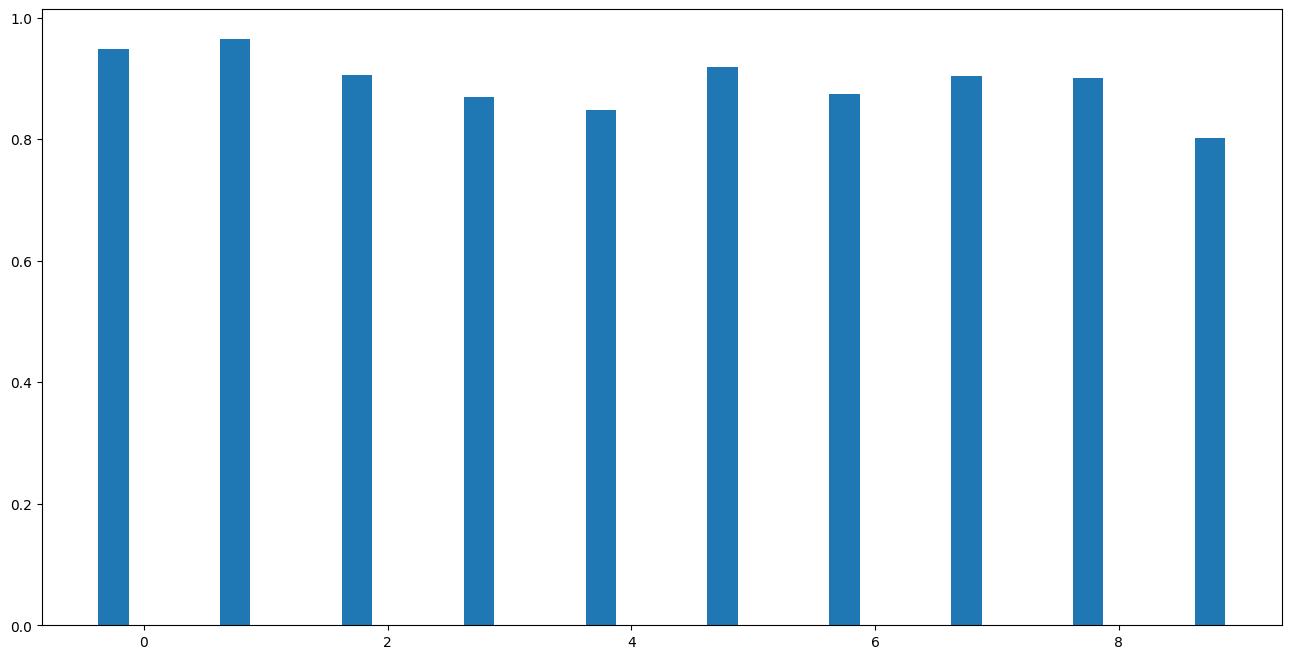

In [3]:
# Cosine similarity function *To be completed*
def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

# Sentences for analysis
main_sentence = "The athlete won a gold medal at the Olympics"
other_sentences = [
    "The female athlete won a bronze medal.",
    "The swimmer won a silver medal.",
    "The runner set a new world record.",
    "The soccer player scored a goal in the final.",
    "The basketball player scored 30 points.",
    "The tennis player won a Grand Slam tournament.",
    "The volleyball player blocked the decisive attack.",
    "The cyclist won a stage of the Tour de France.",
    "The skier had the fastest time in the slalom.",
    "The archer hit the bullseye."
]
sentences = [main_sentence] + other_sentences

# -----------------------------
# GloVe *COMPLETAR*
print("\n GloVe")
def sentence_vec_glove(sentence):
    words = [w for w in sentence.lower().split() if w in glove]
    return np.mean([glove[w]for w in words], axis=0)

main_glove = sentence_vec_glove(main_sentence)
glove_sims = [cosine_sim(main_glove, sentence_vec_glove(s)) for s in other_sentences]

# -----------------------------
# Word2Vec *COMPLETAR*
print("\n Word2Vec")
def sentence_vec_w2v(sentence):
    words = [w for w in sentence.lower().split() if w in w2v]
    return np.mean([w2v[w]for w in words], axis=0)

main_w2v = sentence_vec_w2v(main_sentence)
w2v_sims = [cosine_sim(main_w2v, sentence_vec_w2v(s)) for s in other_sentences]

# -----------------------------
# BERT *COMPLETAR*


# -----------------------------
# Tabla comparativa para cada oración en cada modelo.
labels = other_sentences
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(16, 8))
plt.bar(x - width, glove_sims, width, label='GloVe')
plt.bar(x, w2v_sims, width, label='Word2Vec')
plt.bar(x + width, bert_sims, width, label='BERT')

plt.ylabel('Similarity to the base sentence')
plt.title('Comparison of similarity scores for selected models')
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# Tabla con resultados *COMPLETAR*


### 4. Detector de plagio

In [ ]:
sentence_pairs = [
    ("The cat is sitting on the mat.", "The feline rests on the rug."),
    ("The store closes at 8 PM today.", "The shop shuts its doors at 20:00 today."),
    ("The weather is sunny today.", "It is bright and sunny outside."),
    ("He drove his car to work.", "He took the bus to the office."),
]

for sent1, sent2 in sentence_pairs:
    emb1 = model.encode(sent1, convert_to_tensor=True)
    emb2 = model.encode(sent2, convert_to_tensor=True)
    sim = util.cos_sim(emb1, emb2).item()
    is_paraphrase = sim > 0.65
    print(f"Similarity: {sim:.3f} | Paraphrase: {is_paraphrase}")
    print(f"  1: {sent1}\n  2: {sent2}\n")